# EoR evolution of kSZ reconstruction — with noise

Follows `ksz_reconstruction/functions/generate_all_plots.py` (`analyze_single_redshift`,
`plot_velocity_correlation_vs_neutral_fraction`, `plot_ksz_scale_dependence_and_ell3000`).

For each GRIZZLY snapshot:
1. Build clean `T_b`, true `v_z`, true kSZ map.
2. Add HERA thermal noise (`observe_coeval`) + wedge-confined toy foreground.
3. Build the 3D Wiener filter (`P_s/(P_s+P_n_thermal)`, flat in `k_z`).
4. Reconstruct `v_z` + `kSZ` for **4 scenarios**: clean / noisy / Wiener / Wiener+wedge.
5. Measure the real-space Pearson correlation `r(x)` and the Fourier correlation
   at `ℓ=3000` (i.e. `r(k)` interpolated at `k = 3000/χ(z)`).

Output: two evolution plots vs mean neutral fraction `<xHI>`.

In [8]:
%load_ext autoreload
%autoreload 2
import sys, pathlib, gc
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft
from scipy.integrate import quad
from astropy import units as un

from tuesday.core import (
    observe_coeval, compute_uv_sampling, compute_thermal_rms_uvgrid,
)

from src import grizzly as gz
from src.noise_filters import build_hera_observation

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Config

Pick a subset of GRIZZLY redshifts spanning the EoR. Each snapshot is ~1 GB and the
per-z work (noise + 4 reconstructions) takes a couple of minutes, so 6–10 redshifts
is a reasonable starting point.

In [9]:
DATA_DIR = '../data_grizzly/'

# Use every GRIZZLY redshift available (set to an int to subsample instead)
N_SNAPSHOTS = None          # None → all 51 redshifts

# HERA observation (same as notebook 04)
N_DAYS      = 2 * 180       # 360 days
TRACK_HOURS = 1.0
DISH_M      = 14.0
WEDGE_SLOPE = 1.0

# Toy foreground
FG_AMPLITUDE_MULT = 1000.0  # fg_std = FG × clean T_b std  (wedge-confined)

# kSZ / cosmology (GRIZZLY)
H_KSZ    = 0.7
OMEGA_M  = 0.27
OMEGA_L  = 1.0 - OMEGA_M
OMEGA_B  = 0.045

SEED = 12345

## 2. Pipeline functions

Ported from `ksz_reconstruction/functions/generate_all_plots.py` with the GRIZZLY
cosmology and a wrapper that produces the 4 scenarios per redshift.

In [10]:
_SIGMA_T   = 6.6524587158e-25
_C_KM_S    = 2.99792458e5
_T_CMB     = 2.725e6
_M_P       = 1.6726219e-24
_MPC_TO_CM = 3.085677581e24

def comoving_distance_mpc_h(z, h=H_KSZ, omega_m=OMEGA_M):
    """Comoving distance [Mpc/h]. D_C(z) = (c/H0) ∫ dz'/E(z')."""
    c_over_H0 = 3000.0 / h     # c/H0 in Mpc/h  (c = 3000 Mpc/h * h)
    omega_l = 1.0 - omega_m
    E = lambda zp: np.sqrt(omega_m * (1 + zp) ** 3 + omega_l)
    chi, _ = quad(lambda zp: 1.0 / E(zp), 0, z)
    return chi * c_over_H0

def k_to_ell(k_h_per_mpc, z):
    """Flat-sky k → ell.  ell = k * chi(z)."""
    return k_h_per_mpc * comoving_distance_mpc_h(z)

def pearson_r(a, b):
    af = a.ravel(); bf = b.ravel()
    return float(np.corrcoef(af, bf)[0, 1])


def reconstruct_velocity_z(delta, z, box_len, tracer_field, h=H_KSZ, omega_m=OMEGA_M):
    """Continuity-equation velocity reconstruction from a tracer. Returns km/s."""
    n = delta.shape[0]
    a = 1.0 / (1.0 + z)
    H0 = 100.0 * h
    H_z = H0 * np.sqrt(omega_m * (1 + z) ** 3 + (1 - omega_m))
    f_growth = (omega_m * (1 + z) ** 3 / (omega_m * (1 + z) ** 3 + (1 - omega_m))) ** 0.55

    field = np.asarray(tracer_field, dtype=np.float64) - np.mean(tracer_field)
    field_k = fft.rfftn(field, workers=-1)

    dk = 2.0 * np.pi / box_len
    kx = dk * np.fft.fftfreq(n, d=1.0 / n)
    ky = dk * np.fft.fftfreq(n, d=1.0 / n)
    kz = dk * np.fft.rfftfreq(n, d=1.0 / n)
    kx3, ky3, kz3 = np.meshgrid(kx, ky, kz, indexing='ij')
    k2 = kx3 ** 2 + ky3 ** 2 + kz3 ** 2
    k2[0, 0, 0] = 1.0
    v_z_k = (a * H_z * f_growth) * 1j * kz3 * field_k / k2
    v_z_k[0, 0, 0] = 0.0
    return np.real(fft.irfftn(v_z_k, s=(n, n, n), workers=-1)).astype(np.float32)


def compute_ksz_map(vz, xHI, delta, z, box_len, h=H_KSZ, omega_b=OMEGA_B, axis=2):
    """Project kSZ along LOS. `vz` in km/s, `delta` is overdensity. Returns [µK]."""
    n_cells = delta.shape[axis]
    Y_He = 0.24; X_H = 1.0 - Y_He
    rho_crit_0 = 1.8788e-29 * h ** 2
    n_e_0 = (omega_b * rho_crit_0) / _M_P * (1.0 + X_H) / 2.0
    n_e_z = n_e_0 * (1.0 + z) ** 3
    dl_cm = (box_len / (1.0 + z)) / n_cells * _MPC_TO_CM
    pref = -_T_CMB * _SIGMA_T * n_e_z * dl_cm / _C_KM_S
    x_e = 1.0 - np.clip(xHI, 0.0, 1.0)
    return (pref * np.sum(x_e * (1.0 + delta) * vz, axis=axis)).astype(np.float32)


def fourier_r_2d(map1, map2, box_len, bins=40):
    """Fourier correlation r(k) between two 2D maps (rfft2 binning).
    Mirrors compute_fourier_correlation_coefficient in generate_all_plots.py."""
    f1 = (map1 - map1.mean()).astype(np.float64)
    f2 = (map2 - map2.mean()).astype(np.float64)
    ny, nx = map1.shape
    dx = dy = box_len / nx
    fft1 = np.fft.rfft2(f1)
    fft2 = np.fft.rfft2(f2)
    kx = 2.0 * np.pi * np.fft.fftfreq(ny, d=dx)
    ky = 2.0 * np.pi * np.fft.rfftfreq(nx, d=dy)
    kxg, kyg = np.meshgrid(kx, ky, indexing='ij')
    kmag = np.sqrt(kxg ** 2 + kyg ** 2)
    k_fund = 2.0 * np.pi / box_len
    k_bins = np.linspace(k_fund, kmag.max(), bins + 1)
    k_c = 0.5 * (k_bins[:-1] + k_bins[1:])
    r_k = np.zeros(bins)
    for i in range(bins):
        m = (kmag >= k_bins[i]) & (kmag < k_bins[i + 1])
        if m.any():
            c = np.real(fft1[m] * np.conj(fft2[m])).sum()
            a1 = np.real(fft1[m] * np.conj(fft1[m])).sum()
            a2 = np.real(fft2[m] * np.conj(fft2[m])).sum()
            d = np.sqrt(a1 * a2)
            if d > 0: r_k[i] = c / d
    return k_c, r_k

print('kSZ pipeline functions loaded.')

kSZ pipeline functions loaded.


## 3. Noise, foreground, and Wiener filter for one redshift

`observe_coeval` gives a noisy observation. A toy wedge-confined foreground is
added on top. The Wiener filter is built from `σ_uv²` (analytical, no realizations
needed) + the clean-signal power at each rfftn voxel.

In [11]:
def make_noisy_cube(bt_clean, obs, z, box_len, fg_mult=FG_AMPLITUDE_MULT,
                    wedge_slope=WEDGE_SLOPE, seed=SEED):
    """Return a cube with thermal noise + wedge-confined foreground added."""
    # Thermal noise via observe_coeval
    real = observe_coeval(
        box=bt_clean * un.mK, box_length=box_len * un.Mpc,
        observation=obs, redshift=float(z), nrealizations=1,
        remove_wedge=False, seed=seed,
    )
    bt_noisy = real[0].to(un.mK).value.astype(np.float32)
    bt_noisy = np.nan_to_num(bt_noisy, nan=0.0, posinf=0.0, neginf=0.0)

    # Toy foreground: wedge-confined Gaussian with k_perp^-1 coloring
    n = bt_clean.shape[0]
    dk = 2.0 * np.pi / box_len
    kx = dk * np.fft.fftfreq(n, d=1.0 / n)
    ky = dk * np.fft.fftfreq(n, d=1.0 / n)
    kz = dk * np.fft.rfftfreq(n, d=1.0 / n)
    kx3, ky3, kz3 = np.meshgrid(kx, ky, kz, indexing='ij')
    kperp_3d = np.sqrt(kx3 ** 2 + ky3 ** 2)

    rng = np.random.default_rng(seed + 1)
    fg = rng.standard_normal(bt_clean.shape).astype(np.float32)
    fg_k = fft.rfftn(fg, workers=-1)
    inside = (np.abs(kz3) <= wedge_slope * kperp_3d).astype(np.float32)
    color  = 1.0 / np.maximum(kperp_3d, dk)
    fg_real = np.real(fft.irfftn(fg_k * inside * color, s=bt_clean.shape,
                                  workers=-1)).astype(np.float32)
    fg_real *= (fg_mult * bt_clean.std()) / (fg_real.std() + 1e-12)

    return bt_noisy + fg_real, kperp_3d, kz3


def build_wiener_3d(bt_clean, obs, z, box_len, kperp_3d):
    """3D Wiener filter on the rfftn grid. Thermal noise flat in k_z."""
    n = bt_clean.shape[0]
    freq_obs = 1420.405 * un.MHz / (1 + z)
    _, _, uv_samp = compute_uv_sampling(
        observation=obs, freqs=un.Quantity([freq_obs]),
        box_length=box_len * un.Mpc, box_ncells=n,
        freq_dependent_uv_grid=False,
    )
    sigma_uv = compute_thermal_rms_uvgrid(
        observation=obs, uv_coverage=uv_samp,
        freqs=un.Quantity([freq_obs]), box_length=box_len * un.Mpc,
    )
    # Bin sigma² to 1D P_noise(k_perp), then interpolate onto kperp_3d
    sigma_2d = sigma_uv[:, :, 0].value
    has_bl = sigma_2d > 0
    dk = 2.0 * np.pi / box_len
    kx_fs = np.fft.fftshift(np.fft.fftfreq(n, d=1.0 / n)) * dk
    ky_hp = np.arange(n // 2 + 1) * dk
    kx2, ky2 = np.meshgrid(kx_fs, ky_hp, indexing='ij')
    k_perp_uv = np.sqrt(kx2 ** 2 + ky2 ** 2).ravel()
    P_flat = (sigma_2d ** 2).ravel()
    has_flat = has_bl.ravel()

    nb = 60
    k_max = dk * n / 2
    kp_edges = np.logspace(np.log10(dk * 0.8), np.log10(k_max), nb + 1)
    kp_c = np.sqrt(kp_edges[:-1] * kp_edges[1:])
    ip = np.digitize(k_perp_uv, kp_edges) - 1
    P_n_1d = np.full(nb, 1e30)   # unsampled bins → large value
    for i in range(nb):
        m = (ip == i) & has_flat
        if m.any():
            P_n_1d[i] = np.median(P_flat[m])

    P_noise_3d = np.interp(kperp_3d, kp_c, P_n_1d).astype(np.float32)

    bt_k = fft.rfftn(bt_clean - bt_clean.mean(), workers=-1)
    V = box_len ** 3
    P_signal_3d = (np.abs(bt_k) ** 2 / V).astype(np.float32)

    w3d = np.where((P_signal_3d + P_noise_3d) > 0,
                    P_signal_3d / (P_signal_3d + P_noise_3d), 0.0).astype(np.float32)
    return w3d


def apply_filter(box, w3d, wedge_3d=None):
    box_k = fft.rfftn(box - box.mean(), workers=-1)
    filt = w3d
    if wedge_3d is not None:
        filt = filt * wedge_3d
    return np.real(fft.irfftn(box_k * filt, s=box.shape, workers=-1)).astype(np.float32)

## 4. Main loop — per-redshift analysis

In [12]:
import time

zs_all = gz.available_redshifts(DATA_DIR)
if N_SNAPSHOTS is None or N_SNAPSHOTS >= len(zs_all):
    zs = zs_all
else:
    idx = np.linspace(0, len(zs_all) - 1, N_SNAPSHOTS).astype(int)
    zs = zs_all[idx]
print(f'Running {len(zs)} redshifts: {np.round(zs, 3)}')

# HERA observation (redshift-independent setup)
_, obs, _ = build_hera_observation(
    hex_num=11, split_core=True, outriggers=2,
    dish_size_m=DISH_M, latitude_deg=-30.0,
    track_hours=TRACK_HOURS, time_per_day_hours=TRACK_HOURS, n_days=N_DAYS,
)

# "Wiener" here means the realistic filter: Wiener × wedge mask
SCENARIO_LABELS = ['Clean', 'Noisy', 'Wiener']
ELL_TARGET = 3000

results = []
t0_all = time.time()
for i_z, z in enumerate(zs):
    t0 = time.time()
    print(f'\n── [{i_z+1:2d}/{len(zs)}] z = {z:.3f} ─────────────────────────────')
    den_g, xhi_g, vz_cms = gz.load_snapshot(DATA_DIR, z, crop=True)  # 540^3
    bt = gz.brightness_temp(den_g, xhi_g, z)
    delta = (den_g / den_g.mean() - 1.0).astype(np.float32)
    vz_true = (vz_cms * 1e-5).astype(np.float32)               # cm/s → km/s
    mean_xhi = float(xhi_g.mean())
    box_len = float(gz.BOX_CROP_MPC)
    print(f'   <xHI>={mean_xhi:.3f}   T_b std={bt.std():.2f} mK')

    # True kSZ from simulation velocity
    ksz_true = compute_ksz_map(vz_true, xhi_g, delta, z, box_len)

    # Noisy cube (HERA thermal noise + wedge-confined foreground) + wedge mask + Wiener
    bt_noisy, kperp_3d, kz3 = make_noisy_cube(bt, obs, z, box_len)
    wedge_3d = (np.abs(kz3) > WEDGE_SLOPE * kperp_3d).astype(np.float32)
    w3d = build_wiener_3d(bt, obs, z, box_len, kperp_3d)
    bt_wien = apply_filter(bt_noisy, w3d, wedge_3d)            # Wiener × wedge

    tracers = [('Clean', bt), ('Noisy', bt_noisy), ('Wiener', bt_wien)]
    per_scenario = {}
    for lbl, tracer in tracers:
        vz_rec  = reconstruct_velocity_z(delta, z, box_len, tracer)
        ksz_rec = compute_ksz_map(vz_rec, xhi_g, delta, z, box_len)
        r_x = pearson_r(ksz_true, ksz_rec)
        k_c, r_k = fourier_r_2d(ksz_true, ksz_rec, box_len)
        ell_c = k_to_ell(k_c * H_KSZ, z)
        r_ell3000 = float(np.interp(ELL_TARGET, ell_c, r_k))
        per_scenario[lbl] = dict(r_x=r_x, r_ell3000=r_ell3000,
                                  k_c=k_c, r_k=r_k, ell_c=ell_c)
        print(f'     {lbl:14s}  r(x)={r_x:+.3f}   r(ell=3000)={r_ell3000:+.3f}')

    results.append(dict(z=float(z), xHI=mean_xhi, scenarios=per_scenario))
    del den_g, xhi_g, vz_cms, bt, delta, vz_true, ksz_true
    del bt_noisy, kperp_3d, kz3, wedge_3d, w3d, bt_wien
    gc.collect()
    print(f'   [took {time.time() - t0:.1f} s]')

print(f'\nFinished {len(results)} redshifts in {(time.time() - t0_all) / 60:.1f} min.')

Running 51 redshifts: [ 6.056  6.113  6.172  6.231  6.292  6.354  6.418  6.483  6.549  6.617
  6.686  6.757  6.83   6.905  6.981  7.059  7.139  7.221  7.305  7.391
  7.48   7.57   7.664  7.76   7.859  7.96   8.064  8.172  8.283  8.397
  8.515  8.636  8.762  8.892  9.026  9.164  9.308  9.457  9.611  9.771
  9.938 10.11  10.29  10.478 10.673 10.877 11.09  11.313 11.546 11.791
 12.048]

── [ 1/51] z = 6.056 ─────────────────────────────
   <xHI>=0.000   T_b std=0.00 mK


finding redundancies: 61075ants [00:00, 2551821.14ants/s]


     Clean           r(x)=+nan   r(ell=3000)=+0.000
     Noisy           r(x)=+0.001   r(ell=3000)=-0.006
     Wiener          r(x)=+nan   r(ell=3000)=+0.000
   [took 29.8 s]

── [ 2/51] z = 6.113 ─────────────────────────────
   <xHI>=0.018   T_b std=2.40 mK
     Clean           r(x)=-0.399   r(ell=3000)=-0.471
     Noisy           r(x)=-0.037   r(ell=3000)=-0.047
     Wiener          r(x)=-0.048   r(ell=3000)=-0.079
   [took 30.3 s]

── [ 3/51] z = 6.172 ─────────────────────────────
   <xHI>=0.068   T_b std=4.60 mK
     Clean           r(x)=-0.480   r(ell=3000)=-0.594
     Noisy           r(x)=-0.067   r(ell=3000)=-0.038
     Wiener          r(x)=-0.087   r(ell=3000)=-0.123
   [took 27.1 s]

── [ 4/51] z = 6.231 ─────────────────────────────
   <xHI>=0.116   T_b std=6.00 mK
     Clean           r(x)=-0.517   r(ell=3000)=-0.665
     Noisy           r(x)=-0.096   r(ell=3000)=-0.037
     Wiener          r(x)=-0.084   r(ell=3000)=-0.173
   [took 27.1 s]

── [ 5/51] z = 6.292 ───────────

## 5. Evolution plots: r(x) and r(ℓ=3000) vs `<xHI>`

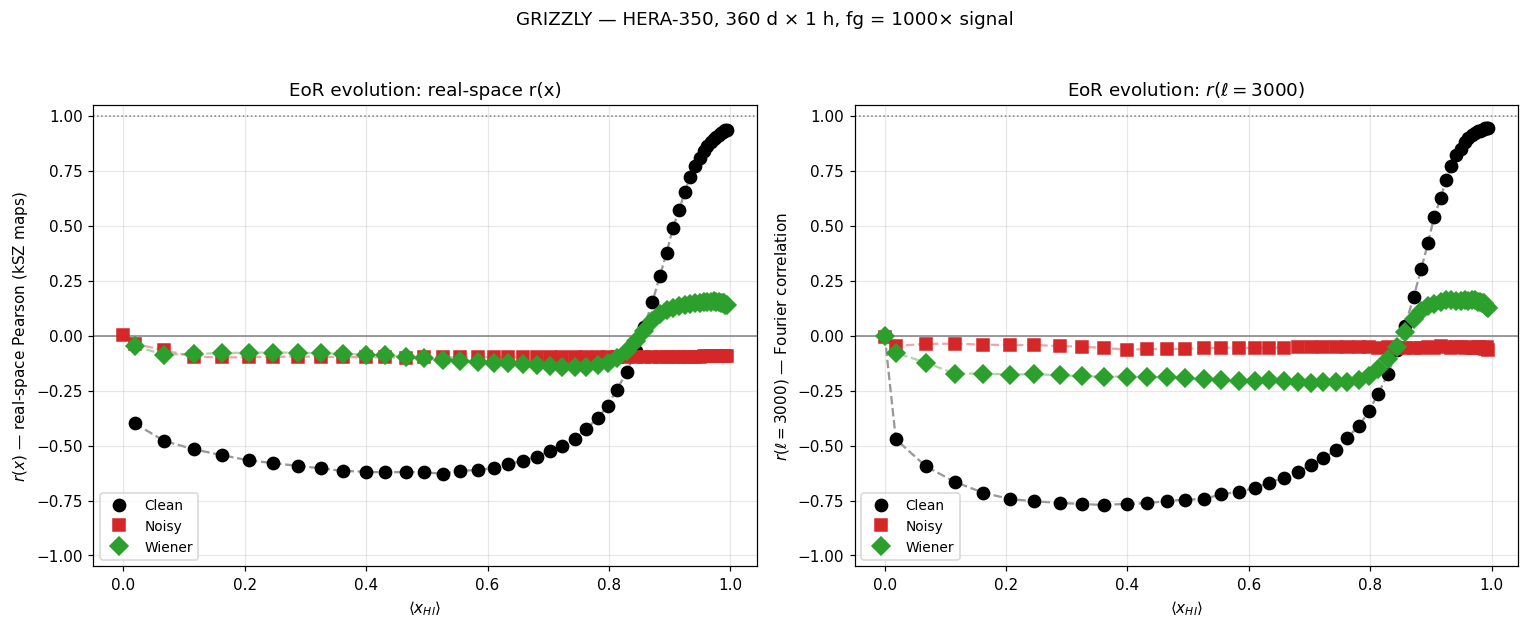

In [13]:
xhi_arr = np.array([r['xHI'] for r in results])
z_arr   = np.array([r['z']   for r in results])
order   = np.argsort(xhi_arr)

colors  = dict(zip(SCENARIO_LABELS, ['k', 'C3', 'C2']))
markers = dict(zip(SCENARIO_LABELS, ['o', 's', 'D']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for lbl in SCENARIO_LABELS:
    y = np.array([r['scenarios'][lbl]['r_x'] for r in results])[order]
    ax.plot(xhi_arr[order], y, '--', color=colors[lbl], alpha=0.4, zorder=1)
    ax.plot(xhi_arr[order], y, marker=markers[lbl], ls='', ms=8,
            color=colors[lbl], label=lbl, zorder=5)
ax.axhline(0, color='gray', lw=1)
ax.axhline(1, color='gray', lw=1, ls=':')
ax.set_xlabel(r'$\langle x_{HI} \rangle$')
ax.set_ylabel(r'$r(x)$ — real-space Pearson (kSZ maps)')
ax.set_title('EoR evolution: real-space r(x)')
ax.set_ylim(-1.05, 1.05)
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='best')

ax = axes[1]
for lbl in SCENARIO_LABELS:
    y = np.array([r['scenarios'][lbl]['r_ell3000'] for r in results])[order]
    ax.plot(xhi_arr[order], y, '--', color=colors[lbl], alpha=0.4, zorder=1)
    ax.plot(xhi_arr[order], y, marker=markers[lbl], ls='', ms=8,
            color=colors[lbl], label=lbl, zorder=5)
ax.axhline(0, color='gray', lw=1)
ax.axhline(1, color='gray', lw=1, ls=':')
ax.set_xlabel(r'$\langle x_{HI} \rangle$')
ax.set_ylabel(r'$r(\ell = 3000)$ — Fourier correlation')
ax.set_title(r'EoR evolution: $r(\ell=3000)$')
ax.set_ylim(-1.05, 1.05)
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='best')

fig.suptitle(f'GRIZZLY — HERA-350, {N_DAYS} d × {TRACK_HOURS:g} h, '
             f'fg = {FG_AMPLITUDE_MULT:g}× signal',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(f'../plots/eor_r_evolution_{N_DAYS}d_{TRACK_HOURS:g}h.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Bonus: `r(k)` curves at a mid-EoR snapshot

Useful sanity check — the `r(ℓ=3000)` value above is just `r(k)` at one point
along these curves (the point where `ℓ = k·χ(z) = 3000`).

Showing r(k) at z=6.905, <xHI>=0.495


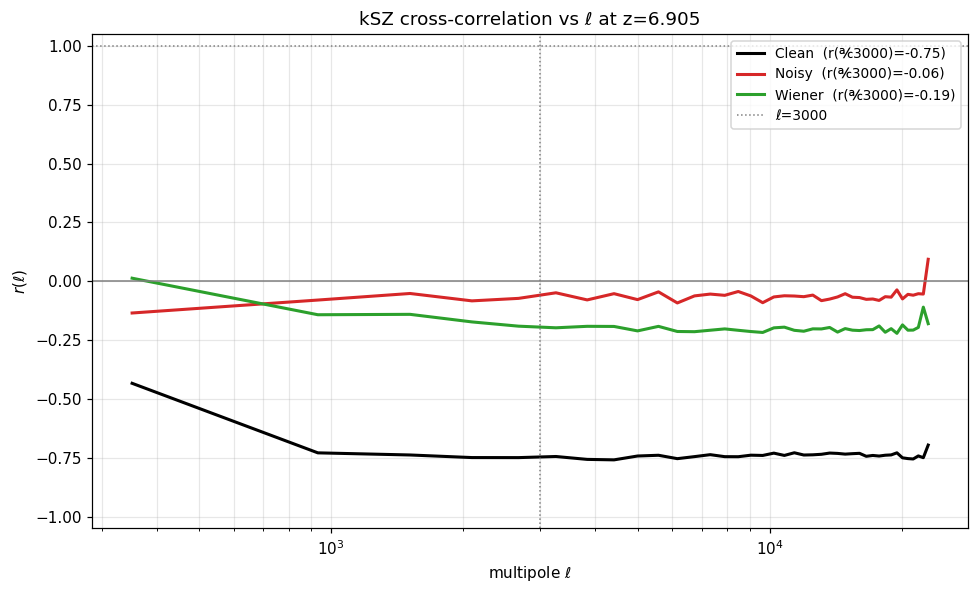

In [14]:
mid = np.argmin(np.abs(xhi_arr - 0.5))
r = results[mid]
print(f'Showing r(k) at z={r["z"]:.3f}, <xHI>={r["xHI"]:.3f}')

fig, ax = plt.subplots(figsize=(9, 5.5))
for lbl in SCENARIO_LABELS:
    s = r['scenarios'][lbl]
    ax.plot(s['ell_c'], s['r_k'], color=colors[lbl], lw=2,
            label=f'{lbl}  (r(℀3000)={s["r_ell3000"]:+.2f})')
ax.axvline(ELL_TARGET, color='gray', ls=':', lw=1, label=f'ℓ={ELL_TARGET}')
ax.axhline(0, color='gray', lw=1)
ax.axhline(1, color='gray', lw=1, ls=':')
ax.set_xscale('log')
ax.set_xlabel(r'multipole $\ell$')
ax.set_ylabel(r'$r(\ell)$')
ax.set_title(f'kSZ cross-correlation vs ℓ at z={r["z"]:.3f}')
ax.set_ylim(-1.05, 1.05)
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'../plots/eor_r_ell_midEoR_z{r["z"]:.2f}.png',
            dpi=150, bbox_inches='tight')
plt.show()